In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder,StandardScaler


In [2]:
data = pd.read_csv("D:\Codink\Project\Machine Learning - Learn\stroke\healthcare-dataset-stroke-data.csv")
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
data = data.drop(columns="id")
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
data.info()
## remove data duplikat
data.drop_duplicates(inplace=True)

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 439.3 KB


In [5]:
## Hapus dataset yang NULL, disini karena data BMI yang null ada 200 dan termasuk kecil kita hapus saja
## Untuk penanganan lainnya sebenarnya bisa kita pakai metode imputation
df = data.dropna()
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4909.000000,4909.000000,4909.000000,4909.000000,4909.000000,4909.000000
mean,42.865374,0.091872,0.049501,105.305150,28.893237,0.042575
std,22.555115,0.288875,0.216934,44.424341,7.854067,0.201917
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.070000,23.500000,0.000000
50%,44.000000,0.000000,0.000000,91.680000,28.100000,0.000000
75%,60.000000,0.000000,0.000000,113.570000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
## Pisahkahn Numerical Features dan Categorical Feature
numerical_features = df.select_dtypes(include=["Int64", "float64"]).columns
categorical_features  = df.select_dtypes(include=["object"]).columns

print("fitur numerik: ", numerical_features)
print("fitur kategori: ", categorical_features)

fitur numerik:  Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'stroke'],
      dtype='str')
fitur kategori:  Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='str')


C:\Users\user\AppData\Local\Temp\ipykernel_16812\382193634.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features  = df.select_dtypes(include=["object"]).columns


In [7]:
for i in categorical_features:
    print(f"fitur {i} memiliki data kategori:\n {df[i].value_counts().reset_index()}")

fitur gender memiliki data kategori:
    gender  count
0  Female   2897
1    Male   2011
2   Other      1
fitur ever_married memiliki data kategori:
   ever_married  count
0          Yes   3204
1           No   1705
fitur work_type memiliki data kategori:
        work_type  count
0        Private   2811
1  Self-employed    775
2       children    671
3       Govt_job    630
4   Never_worked     22
fitur Residence_type memiliki data kategori:
   Residence_type  count
0          Urban   2490
1          Rural   2419
fitur smoking_status memiliki data kategori:
     smoking_status  count
0     never smoked   1852
1          Unknown   1483
2  formerly smoked    837
3           smokes    737


In [8]:
# Karena di di fitur Gender, ada gender "others" yang hanya berisi 1, data kita drop saja
df = df[df["gender"]!= "Other"]
df = df.reset_index(drop=True)

In [9]:
tdf = df['stroke'].value_counts().reset_index()
tdf

,stroke,count
0,0,4699
1,1,209


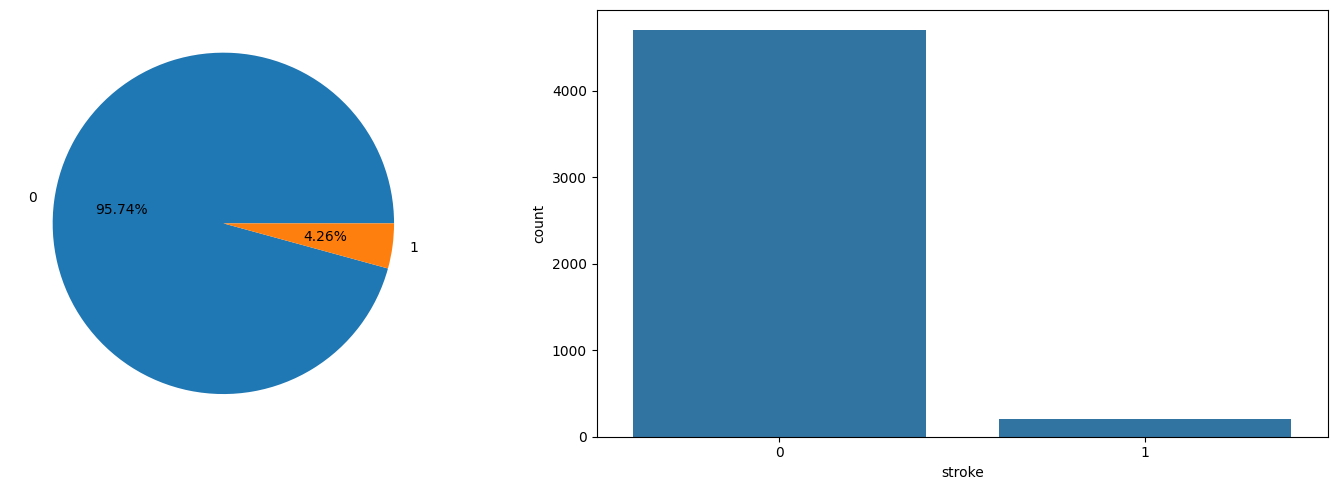

In [10]:
## VIsualisasi Sebaran Data target dalam Dataset ini (PENTING KARENA DAPAT MENGAKIBATKAN OVERFITTING)

fig, ax= plt.subplots(1, 2, figsize=(15, 5))
# Pie Chart
ax[0].pie(labels=tdf['stroke'], x=tdf['count'], autopct='%.2f%%')
# Bar Plot
sns.barplot(data=tdf, x=tdf['stroke'], y=tdf['count'], ax=ax[1])
plt.tight_layout()
plt.show()

#### Dilihat dari sebaran datanya ini sangat jauh, saya akan melakukan 3 Cara disini
##### 1. Normal(polosan) 2. Upsampling Label(1) 3. Undersampling label(0)

In [11]:
df[numerical_features]

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,67.0,0,1,228.69,36.6,1
1,80.0,0,1,105.92,32.5,1
2,49.0,0,0,171.23,34.4,1
3,79.0,1,0,174.12,24.0,1
4,81.0,0,0,186.21,29.0,1
...,...,...,...,...,...,...
4903,13.0,0,0,103.08,18.6,0
4904,81.0,0,0,125.20,40.0,0
4905,35.0,0,0,82.99,30.6,0
4906,51.0,0,0,166.29,25.6,0


In [12]:
# Saya tidak melakukan pengecekan outliers karena dari hasil describe tidak ada nilai yang anomali
# Split data ke Fitur dan Target, dan split ke train dan testing

X = df.drop(columns="stroke")
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, )

# Standarisasi Numeric Features ['age', 'avg_glucose_level', 'bmi'] karena range nilainya berbeda
ss = StandardScaler()
numerik_ss = ['age', 'avg_glucose_level', 'bmi']
X_train[numerik_ss] = ss.fit_transform(X_train[numerik_ss])
X_test[numerik_ss]  = ss.transform(X_test[numerik_ss])

In [13]:
# Coba menggunakan pipeline(Walau belum Paham)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Kelompokkan nama-nama kolom berdasarkan perlakuannya
# Kolom yang butuh distandardisasi
numeric_continuous = ['age', 'avg_glucose_level', 'bmi'] 

# Kolom biner yang sudah 0/1 (jangan disentuh)
numeric_binary = ['hypertension', 'heart_disease'] 

# Kolom kategorikal yang butuh One-Hot Encoding
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# 2. Bangun Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        # Transformer 1: Standarisasi fitur kontinu
        ('num_cont', StandardScaler(), numeric_continuous),
        
        # Transformer 2: OHE untuk fitur kategorikal
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        
        # Transformer 3: Lewatkan saja fitur biner yang sudah aman
        ('num_bin', 'passthrough', numeric_binary)
    ],
    # Jika ada kolom lain yang tertinggal, otomatis dilewati
    remainder='passthrough' 
)
preprocessor.set_output(transform='pandas')
# 3. Fit pada X_train, Transform pada X_train dan X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


In [14]:
X_train_processed

,num_cont__age,num_cont__avg_glucose_level,num_cont__bmi,cat__gender_Female,cat__gender_Male,cat__ever_married_No,cat__ever_married_Yes,cat__work_type_Govt_job,cat__work_type_Never_worked,cat__work_type_Private,cat__work_type_Self-employed,cat__work_type_children,cat__Residence_type_Rural,cat__Residence_type_Urban,cat__smoking_status_Unknown,cat__smoking_status_formerly smoked,cat__smoking_status_never smoked,cat__smoking_status_smokes,num_bin__hypertension,num_bin__heart_disease
3403,-0.129396,-0.888151,0.301936,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0,0
843,0.716733,-0.529584,0.506666,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0,0
2580,0.494068,-0.118597,-0.785692,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0,0
4019,1.696462,-0.765917,-0.632145,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0,0
3366,-1.420855,-0.799809,-1.847729,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,1.562862,-0.987339,-0.580962,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0,0
466,0.360469,-0.500437,0.110001,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0,0
3092,-0.352061,-0.245802,0.711395,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,0
3772,0.805800,0.264372,1.402359,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0,0


In [15]:
X_train_processed.shape

(3926, 20)

In [16]:
# ## Mulai Encoding fitur Categori
# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# X_train[categorical_features] = ohe.fit_transform(X_train[categorical_features])
# X_test[categorical_features] = ohe.transform(X_test[categorical_features])

In [17]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import numpy as np
import time

# Metrics
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, f1_score

# Models
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Imbalanced Learn Pipeline (WAJIB pakai ini, bukan pipeline bawaan sklearn)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# ==========================================
# 1. PABRIK MODEL (Model Factory)
# ==========================================
# Fungsi ini cerdas: ia tahu kapan harus menyalakan class_weight dan kapan harus mematikannya
def get_model(model_name, use_class_weight=False):
    # Asumsi rasio imbalanced (Kelas 0 / Kelas 1) = 95 / 5 = 19
    imbalance_ratio = 19 
    
    if model_name == 'LightGBM':
        return LGBMClassifier(is_unbalance=use_class_weight, random_state=42)
        
    elif model_name == 'XGBoost':
        weight = imbalance_ratio if use_class_weight else 1
        return XGBClassifier(scale_pos_weight=weight, random_state=42, eval_metric='logloss')
        
    elif model_name == 'CatBoost':
        weight_strategy = 'Balanced' if use_class_weight else 'None'
        return CatBoostClassifier(auto_class_weights=weight_strategy, verbose=0, random_state=42)

# ==========================================
# 2. MESIN EVALUATOR
# ==========================================
# Fungsi ini akan melatih, menguji, dan mencatat semua skor
def run_experiment(X_train, y_train, X_test, y_test):
    
    models = ['LightGBM', 'XGBoost', 'CatBoost']
    strategies = {
        '1_Baseline_ClassWeight': None, 
        '2_SMOTE_Upsampling': SMOTE(random_state=42),
        '3_Random_Undersampling': RandomUnderSampler(random_state=42)
    }
    
    results = [] # Untuk menyimpan log eksperimen
    
    # Looping Strategi
    for strat_name, sampler in strategies.items():
        print(f"\n[{strat_name.upper()}]")
        
        # Looping Algoritma
        for model_name in models:
            start_time = time.time()
            
            # Logika "Double-Dip": Nyalakan class_weight HANYA jika tidak ada sampler (Baseline)
            use_weight = True if sampler is None else False
            clf = get_model(model_name, use_class_weight=use_weight)
            
            # Susun Pipeline
            if sampler is None:
                # Jika baseline, langsung pakai modelnya
                pipeline = clf 
            else:
                # Jika pakai SMOTE/Undersampling, gabungkan di ImbPipeline
                pipeline = ImbPipeline([
                    ('sampler', sampler),
                    ('model', clf)
                ])
            
            # Training
            pipeline.fit(X_train, y_train)
            
            # Prediksi
            y_pred = pipeline.predict(X_test)
            y_prob = pipeline.predict_proba(X_test)[:, 1] # Ambil probabilitas kelas 1 (Stroke)
            
            # Evaluasi
            # PR-AUC (Average Precision) adalah metrik TERPENTING untuk data 5% minoritas
            pr_auc = average_precision_score(y_test, y_prob)
            roc_auc = roc_auc_score(y_test, y_prob)
            f1_stroke = f1_score(y_test, y_pred) # F1 khusus kelas 1
            acc_score = accuracy_score(y_test, y_pred)
            
            waktu_eksekusi = time.time() - start_time
            
            # Catat hasil ke log
            results.append({
                'Strategy': strat_name,
                'Model': model_name,
                'PR-AUC': pr_auc,
                'ROC-AUC': roc_auc,
                'F1-Score (Stroke)': f1_stroke,
                'Time (sec)': np.round(waktu_eksekusi, 2),
                'accuracy score' : acc_score
            })
            
            print(f"  ➜ {model_name.ljust(10)} | PR-AUC: {pr_auc:.4f} | F1: {f1_stroke:.4f}")
            
    # Ubah log menjadi DataFrame yang cantik agar mudah dianalisis
    return pd.DataFrame(results)

# ==========================================
# 3. EKSEKUSI (Hanya Butuh 1 Baris!)
# ==========================================
# Asumsi Anda sudah punya X_train, y_train, X_test, y_test hasil ColumnTransformer
df_results = run_experiment(X_train_processed, y_train, X_test_processed, y_test)

# Urutkan berdasarkan skor PR-AUC tertinggi
print("\n=== KLASEMEN AKHIR EKSPERIMEN ===")
df_results_sorted = df_results.sort_values(by='PR-AUC', ascending=False).reset_index(drop=True)
print(df_results_sorted)


[1_BASELINE_CLASSWEIGHT]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 156, number of negative: 3770
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 643
[LightGBM] [Info] Number of data points in the train set: 3926, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039735 -> initscore=-3.184974
[LightGBM] [Info] Start training from score -3.184974
  ➜ LightGBM   | PR-AUC: 0.1551 | F1: 0.1770
  ➜ XGBoost    | PR-AUC: 0.1311 | F1: 0.0952
  ➜ CatBoost   | PR-AUC: 0.1262 | F1: 0.1493

[2_SMOTE_UPSAMPLING]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3770, number of negative: 3770
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000808 seco